In [1]:
### check wireline log inventory from force 2020 competition dataset

In [2]:
### imports
import os
from pathlib import Path

import lasio
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import random
import sys


### pygmt imports
import pyproj
proj_path = os.path.join(sys.prefix, "share", "proj")
pyproj.datadir.set_data_dir(proj_path)
from pyproj import CRS, Transformer
import pygmt

from matplotlib.ticker import FuncFormatter
try:
    import ipympl
except ImportError:
    %pip install ipympl

### pandas displays floats to 2dp for ease of reading
pd.set_option('display.float_format', lambda x: '%.2f' % x)

/Users/user/micromamba/envs/universal/lib/python3.10/site-packages/pyproj/network.py:59: UserWarning: pyproj unable to set PROJ database path.
  _set_context_ca_bundle_path(ca_bundle_path)


In [3]:
### establish unit conversions

FT_PER_M = 3.28084

In [4]:
### make plots interactive
%matplotlib widget

In [5]:
### set project paths 

cwd = Path.cwd()
project_dir = cwd.parent
data_root_dir = project_dir.parent / "data"

def list_contents(dir):
    print(f'\nELEMENTS IN /{os.path.basename(dir)}/:')
    print(f'{sorted(path.name for path in dir.iterdir())}')

list_contents(project_dir)
list_contents(data_root_dir)

data_dir = data_root_dir / 'force_2020_well_log_analysis' / 'Force_2020_all_wells'

LAS_FILES = sorted(data_dir.glob("*.las"))
print(f"LAS files found: {len(LAS_FILES)}")

list_contents(data_dir)


ELEMENTS IN /force_2020_well_log_analysis/:
['.DS_Store', '.git', '.venv', '.vscode', 'README.md', 'notebooks']

ELEMENTS IN /data/:
['.DS_Store', 'force_2020_well_log_analysis']
LAS files found: 118

ELEMENTS IN /Force_2020_all_wells/:
['15_9-13.las', '15_9-14.las', '15_9-15.las', '15_9-17.las', '15_9-23.las', '16_1-2.las', '16_1-6 A.las', '16_10-1.las', '16_10-2.las', '16_10-3.las', '16_10-5.las', '16_11-1 ST3.las', '16_2-11 A.las', '16_2-16.las', '16_2-6.las', '16_2-7.las', '16_4-1.las', '16_5-3.las', '16_7-4.las', '16_7-5.las', '16_7-6.las', '16_8-1.las', '17_11-1.las', '17_4-1.las', '25_10-10.las', '25_10-9.las', '25_11-15.las', '25_11-19 S.las', '25_11-24.las', '25_11-5.las', '25_2-13 T4.las', '25_2-14.las', '25_2-7.las', '25_3-1.las', '25_4-5.las', '25_5-1.las', '25_5-3.las', '25_5-4.las', '25_6-1.las', '25_6-2.las', '25_6-3.las', '25_7-2.las', '25_8-5 S.las', '25_8-7.las', '25_9-1.las', '26_4-1.las', '29_3-1.las', '29_6-1.las', '30_3-3.las', '30_3-5 S.las', '30_6-5.las', '31_2

In [6]:
### make well inventory

### get header values
def get_header_value(las, mnemonic):
    try:
        return las.well[mnemonic].value
    except (KeyError, AttributeError):
        return np.nan

well_records = []
curve_records = []

### iterate over each of 118 wells and get header values, curves and statistics
for path in LAS_FILES:
    try:
        ### get las file path
        las = lasio.read(path)
        df = las.df()

        depth = pd.to_numeric(
            pd.Series(df.index),
            errors="coerce",
        ).dropna().to_numpy()

        depth_difference = np.diff(depth)

        ### get mnemonic header value nd statistics
        well_name = get_header_value(las, "WELL")
        if pd.isna(well_name) or str(well_name).strip() == "":
            well_name = path.stem

        well_records.append(
            {
                "file": path.name,
                "well": str(well_name),
                "samples": len(df),
                "curves": len(df.columns),
                "depth_min": np.nanmin(depth) if len(depth) else np.nan,
                "depth_max": np.nanmax(depth) if len(depth) else np.nan,
                "median_step": (
                    np.nanmedian(np.abs(depth_difference))
                    if len(depth_difference)
                    else np.nan
                ),
                "duplicate_depths": int(df.index.duplicated().sum()),
                "depth_monotonic": bool(
                    np.all(depth_difference > 0)
                    or np.all(depth_difference < 0)
                ),
                "read_error": None,
            }
        )
        
        ### get individual curves and statistics
        for curve in las.curves[1:]:
            mnemonic = curve.mnemonic
            series = (
                pd.to_numeric(df[mnemonic], errors="coerce")
                if mnemonic in df.columns
                else pd.Series(dtype=float)
            )

            curve_records.append(
                {
                    "file": path.name,
                    "well": str(well_name),
                    "curve": mnemonic,
                    "unit": curve.unit,
                    "description": curve.descr,
                    "samples": len(series),
                    "valid_samples": int(series.notna().sum()),
                    "missing_pct": float(series.isna().mean() * 100),
                }
            )

    except Exception as error:
        well_records.append(
            {
                "file": path.name,
                "well": path.stem,
                "samples": np.nan,
                "curves": np.nan,
                "depth_min": np.nan,
                "depth_max": np.nan,
                "median_step": np.nan,
                "duplicate_depths": np.nan,
                "depth_monotonic": np.nan,
                "read_error": str(error),
            }
        )

In [7]:
### test well inventory
well_inventory = pd.DataFrame(well_records)
well_inventory

,file,well,samples,curves,depth_min,depth_max,median_step,duplicate_depths,depth_monotonic,read_error
0,15_9-13.las,15/9-13 Sleipner East Appr,21441,20,25.00,3283.88,0.15,0,True,None
1,15_9-14.las,15/9-14,22875,20,98.80,3575.65,0.15,0,True,None
2,15_9-15.las,15/9-15 Gungne,20954,22,25.00,3209.86,0.15,0,True,None
3,15_9-17.las,15/9-17,19879,21,102.61,3124.07,0.15,0,True,None
4,15_9-23.las,15/9-23 Skardkollen,20494,20,110.00,3224.94,0.15,0,True,None
...,...,...,...,...,...,...,...,...,...,...
113,35_9-7.las,35/9-7,17166,20,397.05,3006.13,0.15,0,True,None
114,35_9-8.las,35/9-8,18842,20,392.02,3255.85,0.15,0,True,None
115,36_7-3.las,36/7-3,16950,16,373.00,2949.25,0.15,0,True,None
116,7_1-1.las,7/1-1,17982,20,82.60,2815.71,0.15,0,True,None


In [8]:
### test curve inventory
curve_inventory = pd.DataFrame(curve_records)
curve_inventory

,file,well,curve,unit,description,samples,valid_samples,missing_pct
0,15_9-13.las,15/9-13 Sleipner East Appr,FORCE_2020_LITHOFACIES_CONFIDENCE,_,FORCE_2020_LITHOFACIES_CONFIDENCE,21441,18277,14.76
1,15_9-13.las,15/9-13 Sleipner East Appr,FORCE_2020_LITHOFACIES_LITHOLOGY,_,FORCE_2020_LITHOFACIES_LITHOLOGY,21441,18270,14.79
2,15_9-13.las,15/9-13 Sleipner East Appr,CALI,in,CALI,21441,18345,14.44
3,15_9-13.las,15/9-13 Sleipner East Appr,MUDWEIGHT,_,MUDWEIGHT,21441,17520,18.29
4,15_9-13.las,15/9-13 Sleipner East Appr,ROP,m/h,ROP,21441,20297,5.34
...,...,...,...,...,...,...,...,...
2270,7_1-2 S.las,7/1-2 S,DRHO,g/cm3,DRHO,19586,1617,91.74
2271,7_1-2 S.las,7/1-2 S,DEPTH_MD,_,DEPTH_MD,19586,19544,0.21
2272,7_1-2 S.las,7/1-2 S,X_LOC,_,x_loc,19586,19544,0.21
2273,7_1-2 S.las,7/1-2 S,Y_LOC,_,y_loc,19586,19544,0.21


In [9]:
# ### make an alphanumeric index for every curve
# curve_names = sorted(curve_inventory["curve"].dropna().unique())

# curve_index = {
#     curve: f"C{i:02d}"
#     for i, curve in enumerate(curve_names, start=1)
# }

# ### add the index to the curve inventory
# curve_inventory["curve_id"] = curve_inventory["curve"].map(curve_index)

# ### test
# curve_key = pd.DataFrame(
#     {
#         "curve_id": list(curve_index.values()),
#         "curve": list(curve_index.keys()),
#     }
# )
# curve_key

In [10]:
### find curve presence for each well
curve_presence = (
    curve_inventory
    .assign(present=True)
    .pivot_table(
        index="well",
        columns="curve",
        values="present",
        aggfunc="any",
        fill_value=False,
    )
    .astype(bool)
)
curve_presence

curve,BS,CALI,DCAL,DEPTH_MD,DRHO,DTC,DTS,FORCE_2020_LITHOFACIES_CONFIDENCE,FORCE_2020_LITHOFACIES_LITHOLOGY,GR,...,RMIC,ROP,ROPA,RSHA,RXO,SGR,SP,X_LOC,Y_LOC,Z_LOC
well,,,,,,,,,,,,,,,,,,,,,
15/9-13 Sleipner East Appr,False,True,False,True,True,True,False,True,True,True,...,False,True,False,True,True,False,True,True,True,True
15/9-14,False,True,False,True,True,True,False,True,True,True,...,False,True,False,True,True,False,True,True,True,True
15/9-15 Gungne,True,True,True,True,True,True,False,True,True,True,...,False,True,False,True,True,False,True,True,True,True
15/9-17,False,True,False,True,True,True,False,True,True,True,...,False,True,False,True,True,True,True,True,True,True
15/9-23 Skardkollen,True,True,True,True,True,True,True,True,True,True,...,False,True,True,False,False,False,False,True,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
35/9-7,True,True,False,True,True,True,True,True,True,True,...,True,True,True,False,False,False,False,True,True,True
35/9-8,True,True,False,True,True,True,True,True,True,True,...,True,True,True,False,False,False,False,True,True,True
36/7-3,False,True,False,True,True,True,False,True,True,True,...,False,False,True,False,False,False,False,True,True,True


In [11]:
### curve availability accross wells
curve_availability = (
    curve_presence
    .sum()
    .sort_values(ascending=False)
    .rename("wells")
    .to_frame()
)

curve_availability["percentage"] = (
    curve_availability["wells"]
    / len(curve_presence)
    * 100
)
curve_availability

,wells,percentage
curve,,
RDEP,118,100.00
FORCE_2020_LITHOFACIES_LITHOLOGY,118,100.00
Y_LOC,118,100.00
X_LOC,118,100.00
RHOB,118,100.00
CALI,118,100.00
NPHI,118,100.00
GR,118,100.00
Z_LOC,118,100.00


In [12]:
### general plotting function
def plot_matrix(matrix):
    plot_matrix = matrix.copy()

    ### binary availability is converted to percentage
    values = plot_matrix.to_numpy()
    finite_values = values[np.isfinite(values)]

    if len(finite_values) and np.all(np.isin(finite_values, [0, 1])):
        plot_matrix = plot_matrix * 100

    fig, ax = plt.subplots(figsize=(12, 20))

    image = ax.imshow(
        plot_matrix,
        aspect="auto",
        interpolation="nearest",
        cmap="RdYlGn",
        vmin=0,
        vmax=100,
    )

    colorbar = fig.colorbar(
        image,
        ax=ax,
        ticks=np.arange(0, 101, 10),
        pad=0.02,
    )
    colorbar.set_label("Availability (%)")

    ax.set_xticks(range(len(matrix.columns)))
    ax.set_xticklabels(matrix.columns)
    ax.tick_params(axis="x", rotation=-40)
    plt.setp(ax.get_xticklabels(), ha="left")

    ax.set_yticks(range(len(matrix.index)))
    ax.set_yticklabels(matrix.index)

    ax.set_xlabel("Curve")
    ax.set_ylabel("Well")
    ax.set_title("FORCE 2020 LAS Curve Availability")

    ax.set_xticks(
        [x - 0.5 for x in range(1, len(matrix.columns))],
        minor=True,
    )
    ax.set_yticks(
        [y - 0.5 for y in range(1, len(matrix.index))],
        minor=True,
    )
    ax.grid(
        which="minor",
        color="black",
        linestyle="-",
        linewidth=0.5,
    )
    ax.tick_params(which="minor", size=0)

    plt.tight_layout()
    plt.show()

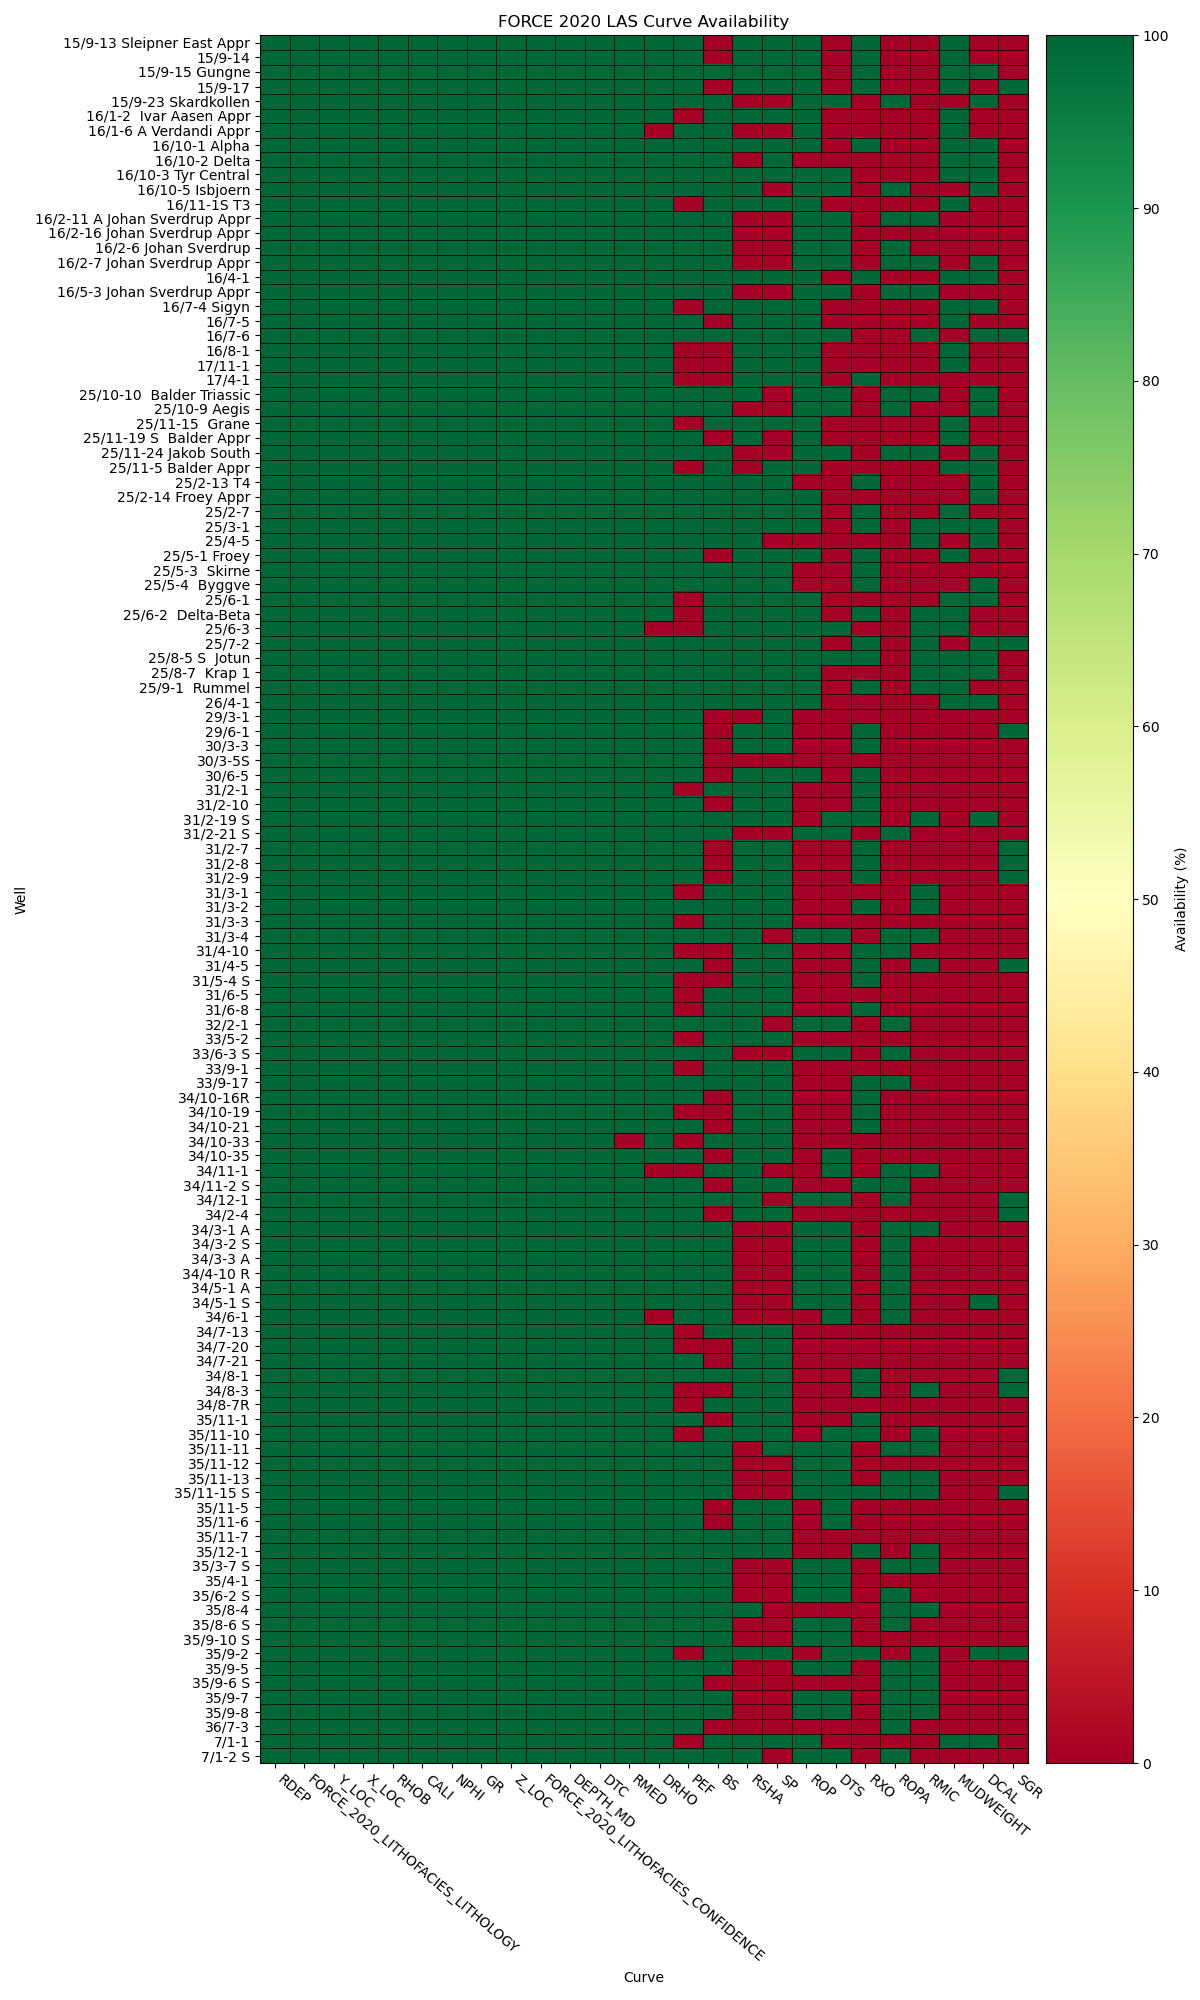

In [13]:
### plot presence
sorted_curves = (
    curve_presence
    .sum()
    .sort_values(ascending=False)
    .index
)

### reorder curve_presence columns using the sorted curve names
curve_presence_matrix = curve_presence[sorted_curves].astype(int)
### curve either 0 or 1 
plot_matrix(curve_presence_matrix)


In [14]:
# ### measure how valid each curve is for each well
# validity_matrix = (
#     curve_inventory
#     .pivot_table(
#         index="well",
#         columns="curve",
#         values="missing_pct",
#     )
# )

# sorted_curves = (
#     (100 - validity_matrix)
#     .sum()
#     .sort_values(ascending=False)
#     .index
# )

# ### reorder validity matrix columns using the sorted curve names
# validity_matrix = validity_matrix[sorted_curves]

# ### curve from 0 to 100
# plot_matrix(validity_matrix)

31_3-2.las

CURVES:
['DEPT', 'FORCE_2020_LITHOFACIES_CONFIDENCE', 'FORCE_2020_LITHOFACIES_LITHOLOGY', 'CALI', 'BS', 'RDEP', 'RSHA', 'RMED', 'RXO', 'RMIC', 'SP', 'DTC', 'NPHI', 'PEF', 'GR', 'RHOB', 'DRHO', 'DEPTH_MD', 'X_LOC', 'Y_LOC', 'Z_LOC']

STRT = 358.30490112 m | 
STOP = 2095.0549316 m | 
STEP = 0.152 m | 
NULL = -999.25  | 
COMP =   | COMPANY
WELL = 31/3-2  | WELL
FLD =   | FIELD
LOC =   | LOCATION
SRVC =   | SERVICE COMPANY
DATE = 2020-08-09 20:01:41   : Log Export Date {yyyy-MM-dd HH:mm  | ss}
PROV =   | PROVINCE
UWI = 31/3-2  | UNIQUE WELL ID
API =   | API NUMBER

Unique location values:
   unique_x  unique_y     x_min     x_max      y_min      y_max
0       167        15 536836.19 536846.56 6748632.50 6748639.50

Trajectory null values:
DEPTH_MD    0
MD_FT       0
X_LOC       0
Y_LOC       0
Z_LOC       0
dtype: int64

Trajectory describe:
       DEPTH_MD    MD_FT     X_LOC      Y_LOC    Z_LOC
count  11413.00 11413.00  11413.00   11413.00 11413.00
mean    1225.92  4022.05 536

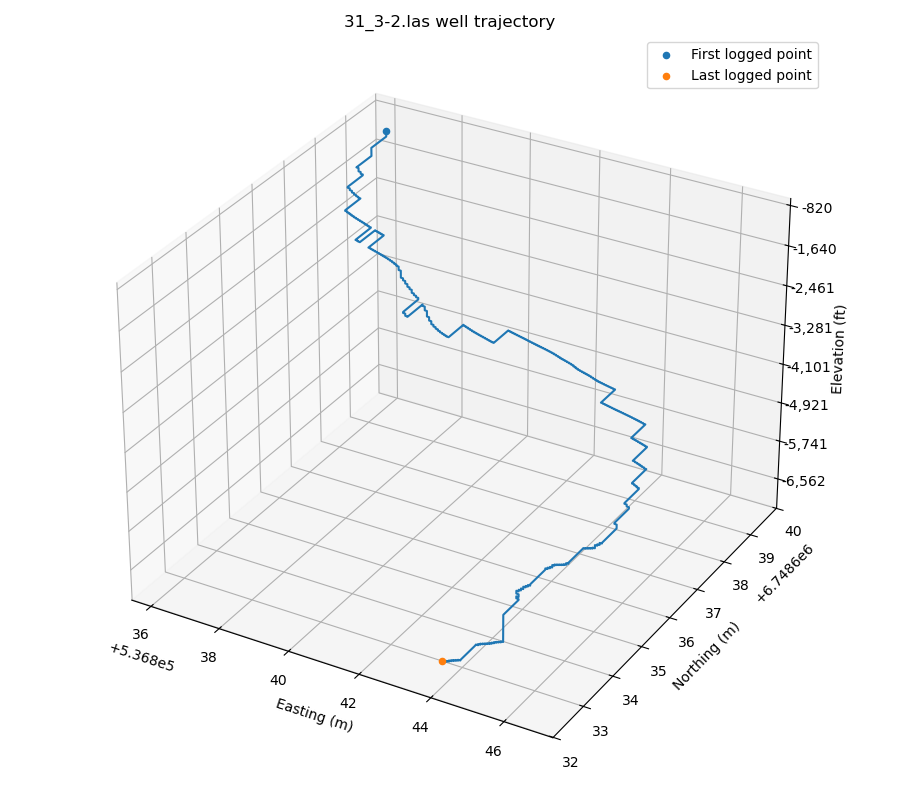

In [57]:
### inspect well trajectory

def inspect_las_trajectory(las_input):
    print(f'{os.path.basename(las_input)}\n')
    ### verbose output
    single_las = lasio.read(las_input)
    
    ### selected output
    curve_names = [curve.mnemonic for curve in single_las.curves]
    print(f'CURVES:\n{curve_names}\n')

    for item in single_las.well:
        print(
            item.mnemonic,
            "=",
            item.value,
            item.unit,
            "|",
            item.descr,
        )

    ### read as pandas df, if x and y coordinates exist print them
        ### x = easting, y = northing
    df = single_las.df()

    ### get measured depth in feet
    df["MD_FT"] = df["DEPTH_MD"] * FT_PER_M

    required = ["DEPTH_MD", "X_LOC", "Y_LOC", "Z_LOC"]

    if all(column in df.columns for column in required):

        xy_check = pd.DataFrame(
            {
                "unique_x": [df["X_LOC"].nunique(dropna=True)],
                "unique_y": [df["Y_LOC"].nunique(dropna=True)],
                "x_min": [df["X_LOC"].min()],
                "x_max": [df["X_LOC"].max()],
                "y_min": [df["Y_LOC"].min()],
                "y_max": [df["Y_LOC"].max()],
            }
        )
        print(f'\nUnique location values:\n{xy_check}\n')

        ### finding: some wells are deviated, not perfectly vertical and so there is a trajectory that varies spatially, measured depth = depth along borehole
        trajectory = df[["DEPTH_MD", 
                        "MD_FT",
                         "X_LOC", 
                         "Y_LOC", 
                         "Z_LOC",
                         ]].dropna().copy()
        print(f'Trajectory null values:\n{trajectory.isna().sum()}')
        print(f'\nTrajectory describe:\n{trajectory.describe().round(2)}')

        first_point = trajectory.iloc[0]
        last_point = trajectory.iloc[-1]

        print(
        "\nFirst valid trajectory point"
        # f"\nMD: {first_point['DEPTH_MD']:.2f}"
        f"\nMD: {first_point['MD_FT']:.2f} ft"
        f"\nX:  {first_point['X_LOC']:.2f} m"
        f"\nY:  {first_point['Y_LOC']:.2f} m"
        f"\nZ:  {first_point['Z_LOC']:.2f} m"
        )

        print(
        "\nLast valid trajectory point"
        # f"\nMD: {last_point['DEPTH_MD']:.2f}"
        f"\nMD: {last_point['MD_FT']:.2f} ft"
        f"\nX:  {last_point['X_LOC']:.2f} m"
        f"\nY:  {last_point['Y_LOC']:.2f} m"
        f"\nZ:  {last_point['Z_LOC']:.2f} m"
        )

        ### 3d plot
        fig = plt.figure(figsize=(9, 8))
        ax = fig.add_subplot(111, projection="3d")

        ax.plot(
            trajectory["X_LOC"],
            trajectory["Y_LOC"],
            trajectory["Z_LOC"],
        )

        ax.scatter(
            trajectory["X_LOC"].iloc[0],
            trajectory["Y_LOC"].iloc[0],
            trajectory["Z_LOC"].iloc[0],
            label="First logged point",
        )

        ax.scatter(
            trajectory["X_LOC"].iloc[-1],
            trajectory["Y_LOC"].iloc[-1],
            trajectory["Z_LOC"].iloc[-1],
            label="Last logged point",
        )

        ax.set_xlabel("Easting (m)")
        ax.set_ylabel("Northing (m)")
        ### instead of earlier route of manually making a new column for z location calculated in ft, this route upholds the native values in meters and formats at the end in feet using matplotlib funcformatter so the values for northing and easting ae geometrically consistent with z location in feet.
        ax.zaxis.set_major_formatter(
        FuncFormatter(lambda value, position: f"{value * FT_PER_M:,.0f}"))
        
        ax.set_zlabel("Elevation (ft)")
        ax.set_title(f"{os.path.basename(las_input)} well trajectory")
        ax.legend()

        plt.tight_layout()
        plt.show()

    else:
        print("\nMISSING location curves")



### test with random las file
random_las = random.choice(LAS_FILES)
inspect_las_trajectory(random_las)

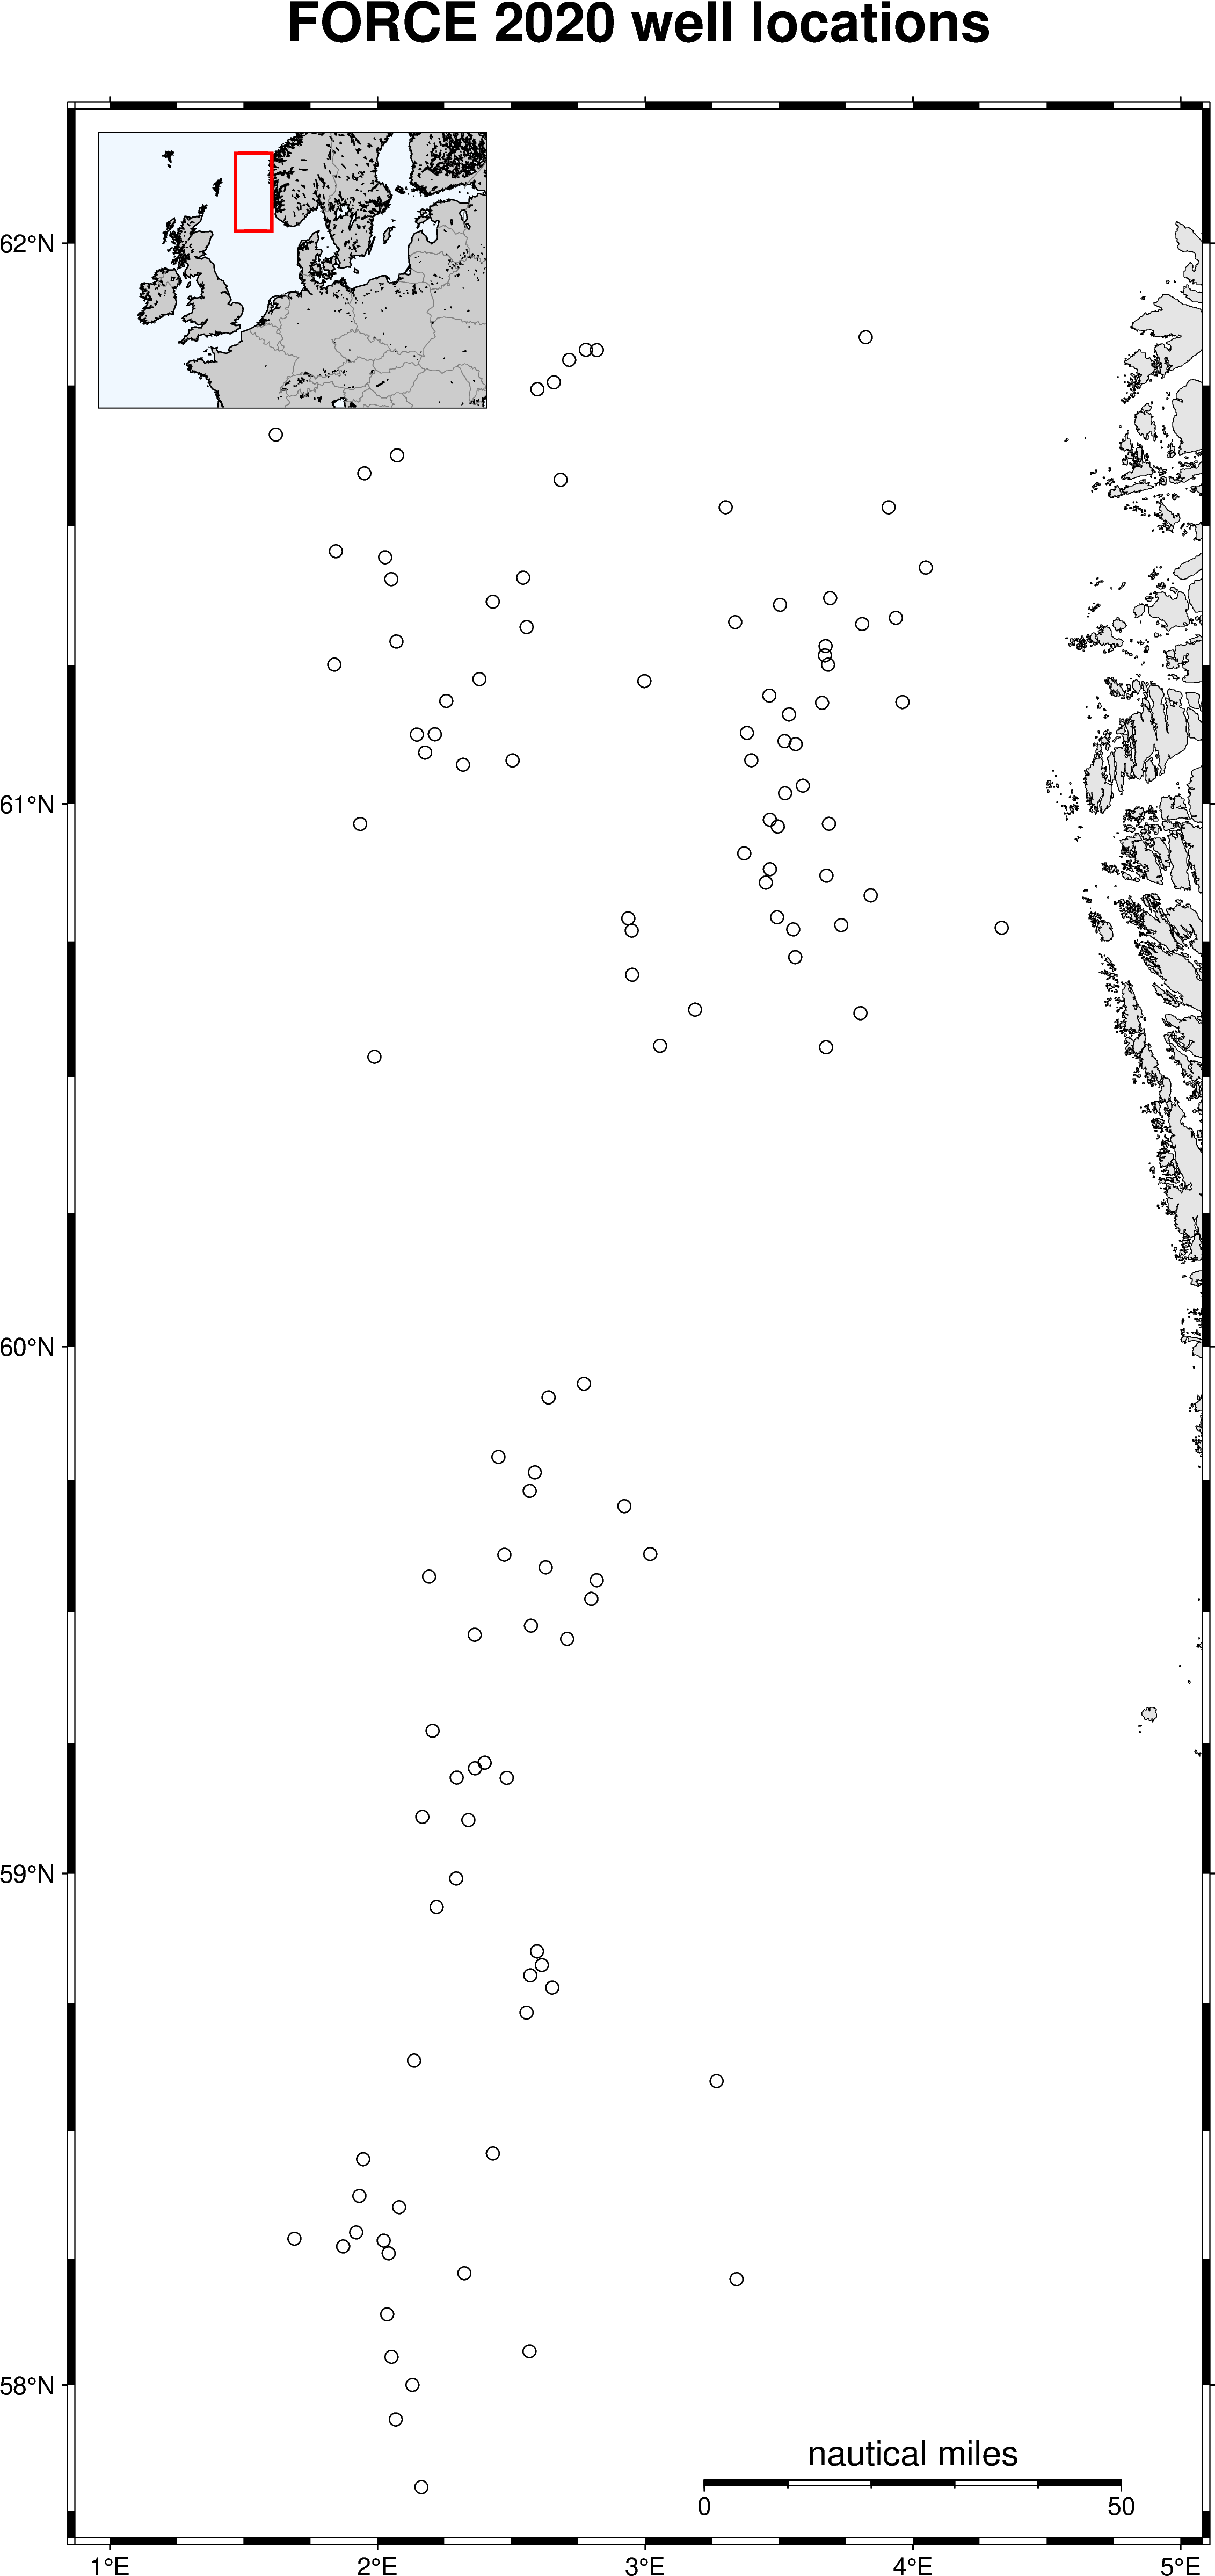

In [ ]:
### plot all the wells in 2d

### make df to get only the shallowest records of a well for mapping
shallow_records = []

for path in LAS_FILES:
    las = lasio.read(path)
    df = las.df()

    required = ["DEPTH_MD", "X_LOC", "Y_LOC", "Z_LOC"]

    if not all(column in df.columns for column in required):
        continue

    location = (
        df[required]
        .dropna()
        .sort_values("DEPTH_MD")
    )

    if location.empty:
        continue

    shallowest = location.iloc[0]

    try:
        well_name = str(las.well["WELL"].value)
    except (KeyError, AttributeError):
        well_name = path.stem

    shallow_records.append(
        {
            "well": well_name,
            "file": path.name,
            "depth_md": shallowest["DEPTH_MD"],
            "easting": shallowest["X_LOC"],
            "northing": shallowest["Y_LOC"],
            "z": shallowest["Z_LOC"],
        }
    )

shallow_points = pd.DataFrame(shallow_records)
print("Wells:", len(shallow_points))


### convert from projected coordinate reference system to lat/long for pygmt to ingest

source_crs = CRS.from_epsg(23031)
map_crs = CRS.from_epsg(4326)

transformer = Transformer.from_crs(
    source_crs,
    map_crs,
    always_xy=True,
)

longitude, latitude = transformer.transform(
    shallow_points["easting"].to_numpy(),
    shallow_points["northing"].to_numpy(),
)

shallow_points["longitude"] = longitude
shallow_points["latitude"] = latitude

shallow_points[
    ["well", "easting", "northing", "longitude", "latitude"]
].head()


### find the map extent for all the wells and pad with margins 

well_bounds = [
    shallow_points["longitude"].min(),
    shallow_points["longitude"].max(),
    shallow_points["latitude"].min(),
    shallow_points["latitude"].max(),
]

longitude_margin = 0.75
latitude_margin = 0.4

map_region = [
    well_bounds[0] - longitude_margin,
    well_bounds[1] + longitude_margin,
    well_bounds[2] - 0.1,
    well_bounds[3] + latitude_margin,
]

### pygmt order is west,east,south,north
print(f'Map extent (degrees of arc):'
      f'Lon {map_region[0]:.2f} to {map_region[1]:.2f}, '
      f'Lat {map_region[2]:.2f} to {map_region[3]:.2f}'
      )

#### plot figure of all the wells

fig = pygmt.Figure()



#### plot figure of all the wells

fig = pygmt.Figure()

fig.coast(
    region=map_region,
    projection="M7i",
    shorelines=True,
    borders="1/0.5p,black",  ### level 1 = national boundaries
    land="gray90",
    water="white",
    frame=["af", "+tFORCE 2020 well locations"],
    ### nautical mile scale bar:
    ### L: specifies a map scale
    ### g<lon>/<lat>: anchor point for scale calculation
    ### +c<lat>: origin latitude where scale is exact
    ### +w<length>N: scale bar width in nautical miles (n = Nautical Miles)
    ### +f: gives scale bar style
    ### +l: adds a label (optional)
    map_scale="g4.0/57.8+c57.8+w50n+f+l",
)

fig.plot(
    x=shallow_points["longitude"],
    y=shallow_points["latitude"],
    style="c0.08i",
    pen="0.5p",
)





### add Europe inset map
###   jTL = j (inside main map) T (top) L (left)
###   +w2.4i/1.7i = inset size
###   +o0.15i/0.15i = offset from border
inset_region=[-15, 30, 45, 70]
with fig.inset(
    position="jTL+w2.4i/1.7i+o0.15i/0.15i",
    box="+gwhite+p1p,black",
):
    fig.coast(
        region=inset_region,
        projection="M2.4i",
        land="gray80",
        water="aliceblue",
        borders="1/0.25p,gray50",
        shorelines="0.5p,black",
        # frame="g",
        
    )

    ### highlight the main map boundary inside the inset
    fig.plot(
        data=[[
            map_region[0],
            map_region[2],
            map_region[1],
            map_region[3],
        ]],
        style="r+s",
        pen="1.5p,red",
        region=inset_region,
        projection="M2.4i",
    )

fig.show()

In [56]:
import plotly.graph_objects as go

### horizontal exaggeration to show well trajectory deviations despite working at large x y scales
horizontal_exaggeration = 50
max_points_per_well = 80

trajectory_records = []

for path in LAS_FILES:
    las = lasio.read(path)
    df = las.df()

    required = ["DEPTH_MD", "X_LOC", "Y_LOC", "Z_LOC"]

    if not all(column in df.columns for column in required):
        continue

    trajectory = (
        df[required]
        .dropna()
        .sort_values("DEPTH_MD")
        .copy()
    )

    if trajectory.empty:
        continue

    try:
        well_name = str(las.well["WELL"].value)
    except (KeyError, AttributeError):
        well_name = path.stem

    ### reduce plotting load while retaining trajectory shape
    if len(trajectory) > max_points_per_well:
        sample_index = np.linspace(
            0,
            len(trajectory) - 1,
            max_points_per_well,
            dtype=int,
        )
        trajectory = trajectory.iloc[np.unique(sample_index)].copy()

    ### use the first logged trajectory point as the exaggeration anchor, effectively pseudo wellhead
    x_anchor = trajectory["X_LOC"].iloc[0]
    y_anchor = trajectory["Y_LOC"].iloc[0]

    ### preserve regional position while exaggerating the deviation
    trajectory["X_EXAG"] = (
        x_anchor
        + horizontal_exaggeration
        * (trajectory["X_LOC"] - x_anchor)
    )

    trajectory["Y_EXAG"] = (
        y_anchor
        + horizontal_exaggeration
        * (trajectory["Y_LOC"] - y_anchor)
    )

    ### make customary unit display fields
    trajectory["MD_FT"] = trajectory["DEPTH_MD"] * FT_PER_M
    trajectory["Z_FT"] = trajectory["Z_LOC"] * FT_PER_M

    trajectory["E_DEV_FT"] = (
        trajectory["X_LOC"] - x_anchor
    ) * FT_PER_M

    trajectory["N_DEV_FT"] = (
        trajectory["Y_LOC"] - y_anchor
    ) * FT_PER_M

    trajectory["H_DEV_FT"] = np.hypot(
        trajectory["E_DEV_FT"],
        trajectory["N_DEV_FT"],
    )

    trajectory["well"] = well_name

    trajectory_records.append(trajectory)

trajectories = pd.concat(
    trajectory_records,
    ignore_index=True,
)

print("Wells:", trajectories["well"].nunique())
print("Plotting points:", len(trajectories))

regional_x0 = trajectories["X_EXAG"].min()
regional_y0 = trajectories["Y_EXAG"].min()

trajectories["X_EXAG_FT"] = (
    trajectories["X_EXAG"] - regional_x0
) * FT_PER_M

trajectories["Y_EXAG_FT"] = (
    trajectories["Y_EXAG"] - regional_y0
) * FT_PER_M







### plotting
fig = go.Figure()

x_span = trajectories["X_EXAG_FT"].max() - trajectories["X_EXAG_FT"].min()
y_span = trajectories["Y_EXAG_FT"].max() - trajectories["Y_EXAG_FT"].min()

xy_max_span = max(x_span, y_span)

x_aspect = x_span / xy_max_span
y_aspect = y_span / xy_max_span

for well, trajectory in trajectories.groupby("well"):
    customdata = np.column_stack(
        [
            trajectory["DEPTH_MD"],
            trajectory["MD_FT"],
            trajectory["X_LOC"],
            trajectory["Y_LOC"],
            trajectory["Z_LOC"],
            trajectory["H_DEV_FT"],
        ]
    )

    fig.add_trace(
        go.Scatter3d(
            x=trajectory["X_EXAG_FT"],
            y=trajectory["Y_EXAG_FT"],
            z=trajectory["Z_FT"],
            mode="lines",
            name=well,
            customdata=customdata,
            hovertemplate=(
                f"<b>{well}</b><br>"
                "MD: %{customdata[1]:,.0f} ft<br>"
                "Elevation: %{z:,.0f} ft<br>"
                "Horizontal deviation: %{customdata[5]:,.0f} ft<br>"
                "Easting: %{customdata[2]:,.1f}<br>"
                "Northing: %{customdata[3]:,.1f}"
                "<extra></extra>"
            ),
            showlegend=False,
        )
    )

fig.update_layout(
    title=(
        "FORCE 2020 well trajectories "
        f"({horizontal_exaggeration}x horizontal exaggeration)"
    ),
    scene=dict(
        xaxis_title="Exaggerated easting (ft)",
        yaxis_title="Exaggerated northing (ft)",
        zaxis_title="Elevation (ft)",
        ### hide overlapping elevation axis
        # zaxis=dict(
        #     showticklabels=False,  ### hides overlapping z-axis tick numbers
        # ),

        aspectmode="manual",
        aspectratio=dict(
            x=x_aspect,
            y=y_aspect,
            z=0.15, ### critical control of how much vertical room the elevation axis takes up in 3d plot
        ),
        ### orbit or turntable work as dragmode parameter
        dragmode="turntable",

        camera = dict(
        # projection=dict(type="orthographic"),
        eye=dict(x=0, y=0, z=2),  ### positioned directly above origin on z-axis
        up=dict(x=1, y=0, z=0),     ### top of screen points along positive x-axis
        center=dict(x=0, y=0, z=0)  ### looking directly at origin
    )
    ),
    height=850,
    margin=dict(
        l=0,
        r=0,
        b=0,
        t=50,
    ),
)

fig.show(
    config={
        "scrollZoom": True,
    }
)

Wells: 118
Plotting points: 9440


In [ ]:

### plotting
fig = go.Figure()

x_span = trajectories["X_EXAG_FT"].max() - trajectories["X_EXAG_FT"].min()
y_span = trajectories["Y_EXAG_FT"].max() - trajectories["Y_EXAG_FT"].min()

xy_max_span = max(x_span, y_span)

x_aspect = x_span / xy_max_span
y_aspect = y_span / xy_max_span





for well, trajectory in trajectories.groupby("well"):
    customdata = np.column_stack(
        [
            trajectory["DEPTH_MD"],
            trajectory["MD_FT"],
            trajectory["X_LOC"],
            trajectory["Y_LOC"],
            trajectory["Z_LOC"],
            trajectory["H_DEV_FT"],
        ]
    )

    fig.add_trace(
        go.Scatter3d(
            x=trajectory["X_EXAG_FT"],
            y=trajectory["Y_EXAG_FT"],
            z=trajectory["Z_FT"],
            mode="lines",
            name=well,
            customdata=customdata,
            hovertemplate=(
                f"<b>{well}</b><br>"
                "MD: %{customdata[1]:,.0f} ft<br>"
                "Elevation: %{z:,.0f} ft<br>"
                "Horizontal deviation: %{customdata[5]:,.0f} ft<br>"
                "Easting: %{customdata[2]:,.1f}<br>"
                "Northing: %{customdata[3]:,.1f}"
                "<extra></extra>"
            ),
            showlegend=False,
        )
    )

fig.update_layout(
    title=(
        "FORCE 2020 well trajectories "
        f"({horizontal_exaggeration}x horizontal exaggeration)"
    ),
    scene=dict(
        xaxis_title="Exaggerated easting (ft)",
        yaxis_title="Exaggerated northing (ft)",
        zaxis_title="Elevation (ft)",
        ### hide overlapping elevation axis
        # zaxis=dict(
        #     showticklabels=False,  ### hides overlapping z-axis tick numbers
        # ),

        aspectmode="manual",
        aspectratio=dict(
            x=x_aspect,
            y=y_aspect,
            z=0.15, ### critical control of how much vertical room the elevation axis takes up in 3d plot
        ),
        ### orbit or turntable work as dragmode parameter
        dragmode="turntable",

        ### get top down view (2d map style)#
    #     camera = dict(
    #     # projection=dict(type="orthographic"),
    #     eye=dict(x=0, y=0, z=2),  ### positioned directly above origin on z-axis
    #     up=dict(x=1, y=0, z=0),     ### top of screen points along positive x-axis
    #     center=dict(x=0, y=0, z=0)  ### looking directly at origin
    # )

    ),
    height=850,
    margin=dict(
        l=0,
        r=0,
        b=0,
        t=50,
    ),
)

fig.show(
    config={
        "scrollZoom": True,
    }
)